MovieWriter imagemagick unavailable; using Pillow instead.


frame: 8162829.0
frame: 8162829.0
frame: 8163226.959183673
frame: 8163624.918367347
frame: 8164022.87755102
frame: 8164420.8367346935
frame: 8164818.795918368
frame: 8165216.755102041
frame: 8165614.714285715
frame: 8166012.673469388
frame: 8166410.632653061
frame: 8166808.591836735
frame: 8167206.551020408
frame: 8167604.510204081
frame: 8168002.469387755
frame: 8168400.428571428
frame: 8168798.3877551025
frame: 8169196.346938776
frame: 8169594.306122449
frame: 8169992.265306123
frame: 8170390.224489796
frame: 8170788.183673469
frame: 8171186.142857143
frame: 8171584.102040816
frame: 8171982.0612244895
frame: 8172380.020408163
frame: 8172777.979591837
frame: 8173175.9387755105
frame: 8173573.897959184
frame: 8173971.857142857
frame: 8174369.816326531
frame: 8174767.775510204
frame: 8175165.734693877
frame: 8175563.693877551
frame: 8175961.653061224
frame: 8176359.6122448975
frame: 8176757.571428572
frame: 8177155.530612245
frame: 8177553.489795919
frame: 8177951.448979592
frame: 81783

frame: 8162829.0


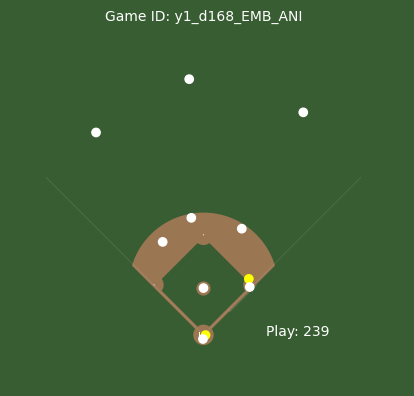

In [ ]:
from IPython.core.display_functions import display
import pandas as pd
from sportypy.surfaces import MiLBField
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML
import pyarrow.dataset as pads
import os

def plot_animation(game_string,
                   play_per_game: int = 1,
                   save_gif: bool = False) -> HTML:
    """    
    Params:
        player_position_df: A Data Frame for the player position coordinates on a field.
        ball_position_df: A Data Frame for the ball position coordiantes on a field.
        play_per_game: A integer field that denotes the play id you want to visualize. Defaults to 1.
        save_gif: A boolean that when set to true saves the animation to a gif.
                  Defaults to not saving animation (False).
   
    Returns:
        HTML display of the animation. You can slow or speed up the fps with the + and - buttons.
        You can also press the > arrow to start the animation.
    """
    game_str_split = game_string.split('_')
    find_game = game_str_split[3] +'/'+ game_str_split[2]+'/y1/'+game_str_split[1]
    player_position_df = readDataSubset('player-positions/' + find_game + '/player-positions.csv').to_table().to_pandas()
    ball_position_df = readDataSubset('ball-positions/' + find_game + '/ball-positions.csv').to_table().to_pandas()

    # Remove plays with NAs forr game string and/or timestamp
    player_position_df = player_position_df[(player_position_df['timestamp'] != "NA") & (player_position_df['game_string'] != "NA")]
    ball_position_df = ball_position_df[(ball_position_df['timestamp'] != "NA") & (ball_position_df['game_string'] != "NA")]
   

    if not isinstance(play_per_game, int):
        raise ValueError("Play ID must be an Integer. This function only handles one Play ID.")

    # print(player_position_df['game_string'].unique())
    if len(player_position_df['game_string'].unique()) > 1 or len(ball_position_df['game_string'].unique()) > 1:
        raise ValueError("Player Position or Ball Position Data Frame has multiple games. Please filter for one game at a time.")

    player_pos = player_position_df.query(f'play_per_game == {play_per_game}')
    ball_pos = ball_position_df.query(f'play_per_game == {play_per_game}')
   
    merged_df = pd.merge(player_pos, ball_pos, on = ['timestamp', 'play_per_game', 'game_string'], how = 'left')
    merged_df = merged_df[merged_df['player_id'] < 14] # Elminate umpires and coaches on field
   
    field = MiLBField()
    field.draw(display_range='full')


    fig = plt.gcf()
    ax = plt.gca()

    # create base arrays for player and ball points

    p = field.scatter([], [], c='white')
    b = field.scatter([], [], c='red')    

    game_id = merged_df['game_string'].unique()[0]
    game_text = ax.text(0, 400, f'Game ID: {game_id}', c='white', ha='center')
    play_text = ax.text(120, 0, f'Play: {play_per_game}', c='white', ha='center')

    # Update coords, colors, sizes, for each frame
    def update(frame):
        print(f"frame: {frame}")
        merged_df.to_csv("test_merge_df.csv")
        frame_data = merged_df[merged_df['timestamp'] <= frame] 


        # Set player coords and colors
        players = frame_data.sort_values('timestamp').drop_duplicates(subset=['player_id'], keep='last')
        players_colors = ['yellow' if 10 <= pos <= 13 else 'white' for pos in players['player_id']]
        p.set_offsets(np.c_[players['field_x'], players['field_y']])
        p.set_color(players_colors)


        # Set ball coordinates
        balls = frame_data[['ball_position_x', 'ball_position_y', 'ball_position_z']].dropna().iloc[-1:]
        ball_offsets = np.c_[balls['ball_position_x'], balls['ball_position_y']]
        b.set_offsets(ball_offsets)

        # Set ball size based on height
        ball_z = balls['ball_position_z']
        if len(ball_z) == 0:
            b.set_sizes([1])
        else:
            b.set_sizes(
                [
                    2 * math.pow(int(abs(
                        min(6, balls['ball_position_z'].iloc[0]))), 0.8)
                ])


        return p, b


    ani = FuncAnimation(fig, update, frames=np.linspace(merged_df['timestamp'].min(),
                                                        merged_df['timestamp'].max(), 50
                                                        ), blit=False)

    if save_gif:
        ani.save('animation.gif', writer='imagemagick', fps=5)
   
    return HTML(ani.to_jshtml())
    HTML(ani.to_jshtml())


def readDataSubset(table_type, data_path="data/"):


    if table_type == 'lineups' or table_type == 'game-info':
        return pads.dataset(source = os.path.join(os.path.dirname(__name__), data_path, table_type + '.csv'), format = 'csv')
    else:
        return pads.dataset(source = os.path.join(os.path.dirname(__name__), data_path, table_type), format = 'csv', partitioning = ['home_team', 'away_team', 'year', 'day'])


def main():

    play_ball = plot_animation(game_string = "y1_d168_EMB_ANI", play_per_game =  239, save_gif=True)

    return play_ball
   

display(main())